# 05 - Google Play Store Exploratory Data Analysis & Customer Voice
Eksplorasi mendalam ulasan pengguna Google Play Store pada ekosistem aplikasi Zahir Accounting untuk memetakan profil rating, perbandingan antar-aplikasi, tren temporal, responsivitas pengembang, keterlibatan (*thumbs-up*), karakteristik teks ulasan, serta observasi awal Customer Voice.


## 1. Objective & Scope
Tujuan dari tahap Exploratory Data Analysis (EDA) ini adalah:
1. Menganalisis profil distribusi rating keseluruhan dan proporsi kategori rating (*rating-based category*).
2. Membandingkan performa kepuasan pengguna antar-5 aplikasi ekosistem Zahir (*Zahir Simple Start, Zahir Online, POS X, Zahir Certification, Zahir Attendance*).
3. Mengidentifikasi dinamika temporal volume ulasan dan evolusi skor rating dari tahun 2018 hingga 2026.
4. Mengevaluasi pola dan cakupan balasan pengembang (*developer response behavior*).
5. Menganalisis distribusi waktu tanggap developer (*response time*) dengan pemisahan eksplisit terhadap 15 kasus artefak ulasan yang diperbarui pengguna.
6. Memeriksa sinyal keterlibatan ulasan melalui metrik upvote (*thumbsUpCount*).
7. Menganalisis karakteristik panjang teks ulasan (*character length & word count*) terhadap rating.
8. Melakukan eksplorasi lintas-variabel (*cross-variable exploration*).
9. Merumuskan observasi kualitatif awal Customer Voice dan menyusun daftar pertanyaan penelitian untuk memandu fase NLP lanjutan.

**Batasan Eksploratori Penting**:
Fase ini bersifat deskriptif-analitis murni. Tidak dilakukan klasifikasi sentimen berbasis machine learning/transformer, topic modeling (LDA/BERTopic), pembobotan TF-IDF, clustering, maupun penentuan sentimen otomatis dari teks ulasan.


## 2. Environment Setup & Data Validation
Mengimpor pustaka komputasi numerik, visualisasi data, dan memverifikasi integritas dataset olahan dari `data/final/playstore_reviews_final.csv`.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Segoe UI, Arial, sans-serif'
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8

if os.path.exists(os.path.join('data', 'final', 'playstore_reviews_final.csv')):
    dataset_path = os.path.join('data', 'final', 'playstore_reviews_final.csv')
else:
    dataset_path = os.path.join('..', 'data', 'final', 'playstore_reviews_final.csv')
assert os.path.exists(dataset_path), f'Dataset tidak ditemukan di {dataset_path}!'

df = pd.read_csv(dataset_path)
print(f'Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom.')

assert len(df) == 417, 'Ekspektasi 417 baris!'
assert len(df.columns) == 21, 'Ekspektasi 21 kolom!'
assert df['review_id'].nunique() == 417, 'review_id tidak unik!'
assert df['score'].between(1, 5).all(), 'Score di luar 1-5!'
assert df['app_name'].nunique() == 5, 'Jumlah aplikasi != 5!'
print('Seluruh 5 pemeriksaan pra-EDA lolos 100%.')


Dataset berhasil dimuat: 417 baris, 21 kolom.
Seluruh 5 pemeriksaan pra-EDA lolos 100%.


## 3. Dataset Summary Statistics
Ringkasan metrik deskriptif menyeluruh dari 417 ulasan pengguna Google Play Store.


In [2]:
total_reviews = len(df)
num_apps = df['app_name'].nunique()
min_date = df['review_date'].min()
max_date = df['review_date'].max()
mean_score = df['score'].mean()
median_score = df['score'].median()
std_score = df['score'].std()

reply_cov = df['has_developer_reply'].mean() * 100
replied_reviews = df['has_developer_reply'].sum()

valid_resp_times = df[df['has_developer_reply'] & (df['response_time_days'] >= 0)]['response_time_days']
median_resp_days = valid_resp_times.median()
mean_resp_days = valid_resp_times.mean()

median_text_len = df['text_length_chars'].median()
mean_text_len = df['text_length_chars'].mean()
median_word_cnt = df['word_count'].median()

pos_pct = (df['rating_category'] == 'positive').mean() * 100
pos_cnt = (df['rating_category'] == 'positive').sum()
crit_pct = (df['rating_category'] == 'critical').mean() * 100
crit_cnt = (df['rating_category'] == 'critical').sum()
neut_pct = (df['rating_category'] == 'neutral').mean() * 100
neut_cnt = (df['rating_category'] == 'neutral').sum()

summary_metrics = pd.DataFrame({
    'Metric': [
        'Total Ulasan Terverifikasi',
        'Jumlah Aplikasi Ekosistem',
        'Rentang Tanggal Ulasan',
        'Rata-rata Rating Bintang (Mean Score)',
        'Median Rating Bintang',
        'Standar Deviasi Rating',
        'Proporsi Kategori Positif (Bintang 4-5)',
        'Proporsi Kategori Kritis (Bintang 1-2)',
        'Proporsi Kategori Netral (Bintang 3)',
        'Cakupan Balasan Developer (Reply Coverage)',
        'Median Waktu Respon Developer (Hari)',
        'Rata-rata Waktu Respon Developer (Hari)',
        'Median Panjang Karakter Ulasan',
        'Rata-rata Panjang Karakter Ulasan',
        'Median Jumlah Kata Ulasan'
    ],
    'Nilai': [
        f'{total_reviews} ulasan',
        f'{num_apps} aplikasi',
        f'{min_date} s/d {max_date}',
        f'{mean_score:.2f} / 5.00',
        f'{median_score:.1f} / 5.00',
        f'{std_score:.2f}',
        f'{pos_pct:.1f}% ({pos_cnt} ulasan)',
        f'{crit_pct:.1f}% ({crit_cnt} ulasan)',
        f'{neut_pct:.1f}% ({neut_cnt} ulasan)',
        f'{reply_cov:.1f}% ({replied_reviews} ulasan)',
        f'{median_resp_days:.2f} hari (~{median_resp_days*24:.1f} jam)',
        f'{mean_resp_days:.2f} hari',
        f'{median_text_len:.0f} karakter',
        f'{mean_text_len:.1f} karakter',
        f'{median_word_cnt:.0f} kata'
    ]
})
summary_metrics


,Metric,Nilai
0,Total Ulasan Terverifikasi,417 ulasan
1,Jumlah Aplikasi Ekosistem,5 aplikasi
2,Rentang Tanggal Ulasan,2018-01-26 s/d 2026-09-11
3,Rata-rata Rating Bintang (Mean Score),3.84 / 5.00
4,Median Rating Bintang,5.0 / 5.00
5,Standar Deviasi Rating,1.59
6,Proporsi Kategori Positif (Bintang 4-5),66.9% (279 ulasan)
7,Proporsi Kategori Kritis (Bintang 1-2),24.2% (101 ulasan)
8,Proporsi Kategori Netral (Bintang 3),8.9% (37 ulasan)
9,Cakupan Balasan Developer (Reply Coverage),87.8% (366 ulasan)


## 4. Overall Rating Profile & Distribution
Menganalisis sebaran rating bintang 1 hingga 5 serta komposisi kategori rating pendukung.

**Pertanyaan Analitis**:
Apakah distribusi rating menunjukkan pola *J-shaped curve* yang umum pada aplikasi mobile (mayoritas bintang 5 dengan sedikit bintang 1)?


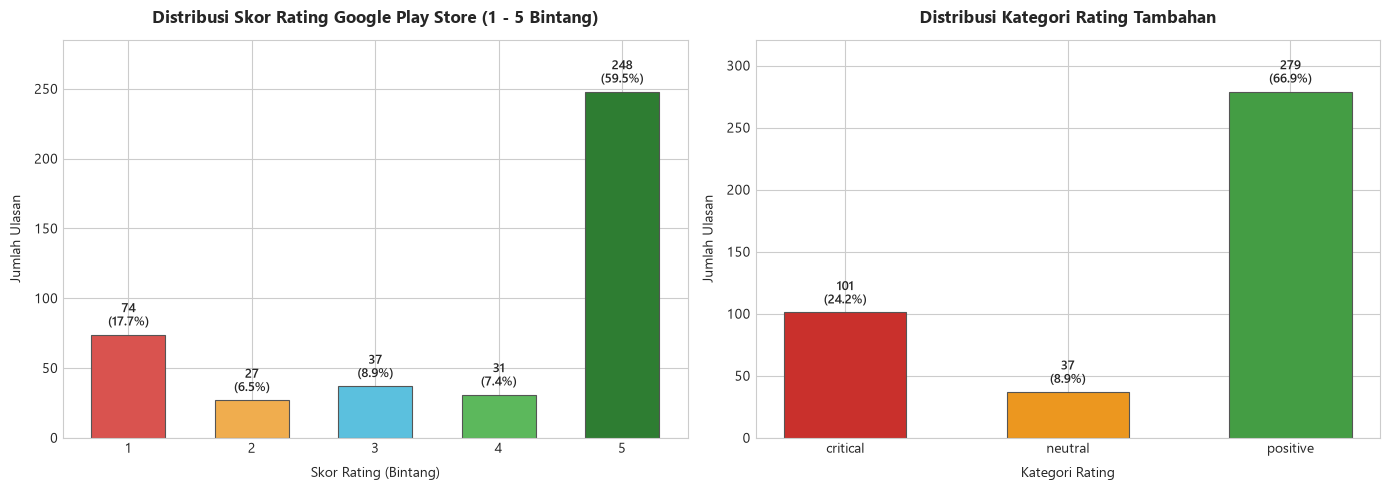

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

score_counts = df['score'].value_counts().sort_index()
score_pcts = (score_counts / len(df)) * 100
colors_score = ['#D9534F', '#F0AD4E', '#5BC0DE', '#5CB85C', '#2E7D32']

bars1 = axes[0].bar(score_counts.index, score_counts.values, color=colors_score, width=0.6, edgecolor='#555555', linewidth=0.8)
axes[0].set_title('Distribusi Skor Rating Google Play Store (1 - 5 Bintang)', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Skor Rating (Bintang)', fontsize=10, labelpad=8)
axes[0].set_ylabel('Jumlah Ulasan', fontsize=10, labelpad=8)
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_ylim(0, max(score_counts.values) * 1.15)

for bar, pct in zip(bars1, score_pcts):
    h = bar.get_height()
    axes[0].annotate(f'{h}\n({pct:.1f}%)', xy=(bar.get_x() + bar.get_width() / 2, h),
                     xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=9, fontweight='semibold')

cat_order = ['critical', 'neutral', 'positive']
cat_counts = df['rating_category'].value_counts().reindex(cat_order)
cat_pcts = (cat_counts / len(df)) * 100
colors_cat = ['#C9302C', '#EC971F', '#449D44']

bars2 = axes[1].bar(cat_counts.index, cat_counts.values, color=colors_cat, width=0.55, edgecolor='#555555', linewidth=0.8)
axes[1].set_title('Distribusi Kategori Rating Tambahan', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Kategori Rating', fontsize=10, labelpad=8)
axes[1].set_ylabel('Jumlah Ulasan', fontsize=10, labelpad=8)
axes[1].set_ylim(0, max(cat_counts.values) * 1.15)

for bar, pct in zip(bars2, cat_pcts):
    h = bar.get_height()
    axes[1].annotate(f'{h}\n({pct:.1f}%)', xy=(bar.get_x() + bar.get_width() / 2, h),
                     xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=9, fontweight='semibold')

plt.tight_layout()
plt.show()


**Interpretasi & Implikasi**:
- Distribusi rating memperlihatkan polaritas bimodal berbentuk *J-curve*: bintang 5 mendominasi secara absolut dengan 248 ulasan (59.5%), disusul oleh bintang 1 sebanyak 74 ulasan (17.7%). Rating moderat (bintang 2, 3, 4) masing-masing berada di bawah 9%.
- Berdasarkan kategori rating, kelompok **positif** mencakup 66.9% ulasan, sedangkan kelompok **kritis** mencapai 24.2% (hampir seperempat dari seluruh feedback pengguna). Kelompok **netral** adalah minoritas (8.9%).
- *Implikasi*: Umpan balik pengguna didominasi oleh kepuasan kuat dan keluhan serius. Kelompok kritis sebesar 24.2% mengindikasikan adanya kendala fungsional atau teknis yang memicu resistensi pengguna.


## 5. Perbandingan Rating Antar-Aplikasi Ekosistem Zahir
Membandingkan profil kepuasan dan volume ulasan pada 5 aplikasi yang berbeda.

**Pertanyaan Analitis**:
Apakah setiap aplikasi di ekosistem Zahir memiliki persepsi kepuasan yang seragam, ataukah terdapat aplikasi tertentu dengan konsentrasi ulasan kritis yang jauh lebih tinggi?


,total_reviews,mean_score,median_score,std_score,pct_critical,pct_neutral,pct_positive,reply_rate
app_name,,,,,,,,
Zahir Simple Start,160,4.19,5.0,1.39,14.37,9.38,76.25,95.62
Zahir Online,98,3.33,4.0,1.75,36.73,11.22,52.04,94.90
POS X,87,4.07,5.0,1.47,18.39,6.90,74.71,85.06
Zahir Certification,44,3.05,2.5,1.70,50.00,9.09,40.91,45.45
Zahir Attendance,28,4.25,5.0,1.43,14.29,3.57,82.14,92.86


C:\Users\Yafi Rafsanjani H\AppData\Local\Temp\ipykernel_30168\355761944.py:39: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Segoe UI.
  plt.tight_layout()
D:\FILE KULIAH\semester 5\magang\zahir_social_analytics\.venv_social\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)


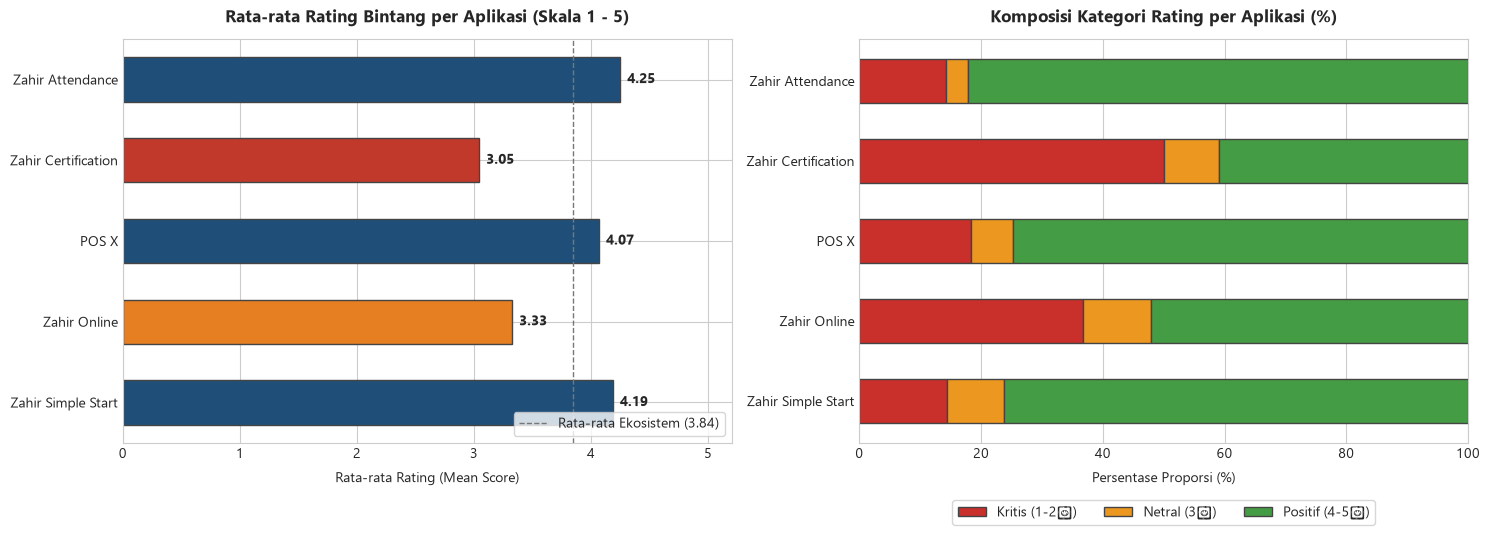

In [4]:
app_comp = df.groupby('app_name').agg(
    total_reviews=('score', 'count'),
    mean_score=('score', 'mean'),
    median_score=('score', 'median'),
    std_score=('score', 'std'),
    pct_critical=('rating_category', lambda s: (s == 'critical').mean() * 100),
    pct_neutral=('rating_category', lambda s: (s == 'neutral').mean() * 100),
    pct_positive=('rating_category', lambda s: (s == 'positive').mean() * 100),
    reply_rate=('has_developer_reply', lambda s: s.mean() * 100)
).loc[['Zahir Simple Start', 'Zahir Online', 'POS X', 'Zahir Certification', 'Zahir Attendance']]

display(app_comp.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

colors_bar = ['#1F4E79' if m >= 4.0 else '#E67E22' if m >= 3.3 else '#C0392B' for m in app_comp['mean_score']]
bars_app = axes[0].barh(app_comp.index, app_comp['mean_score'], color=colors_bar, height=0.55, edgecolor='#444444')
axes[0].set_title('Rata-rata Rating Bintang per Aplikasi (Skala 1 - 5)', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Rata-rata Rating (Mean Score)', fontsize=10, labelpad=8)
axes[0].set_xlim(0, 5.2)
axes[0].axvline(df['score'].mean(), color='#777777', linestyle='--', linewidth=1, label=f'Rata-rata Ekosistem ({df["score"].mean():.2f})')
axes[0].legend(loc='lower right', frameon=True)

for bar in bars_app:
    w = bar.get_width()
    axes[0].annotate(f'{w:.2f}', xy=(w, bar.get_y() + bar.get_height() / 2),
                     xytext=(5, 0), textcoords='offset points', va='center', ha='left', fontsize=10, fontweight='bold')

app_cat_crosstab = pd.crosstab(df['app_name'], df['rating_category'], normalize='index')[['critical', 'neutral', 'positive']] * 100
app_cat_crosstab = app_cat_crosstab.reindex(app_comp.index)

app_cat_crosstab.plot(kind='barh', stacked=True, color=['#C9302C', '#EC971F', '#449D44'], ax=axes[1], edgecolor='#444444', width=0.55)
axes[1].set_title('Komposisi Kategori Rating per Aplikasi (%)', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Persentase Proporsi (%)', fontsize=10, labelpad=8)
axes[1].set_ylabel('')
axes[1].set_xlim(0, 100)
axes[1].legend(['Kritis (1-2★)', 'Netral (3★)', 'Positif (4-5★)'], loc='lower center', bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=True)

plt.tight_layout()
plt.show()


**Interpretasi & Implikasi**:
- **Variasi Kepuasan Signifikan Antar-Aplikasi**:
  - `Zahir Attendance` (4.25★) dan `Zahir Simple Start` (4.19★) memimpin dengan rating tertinggi dan proporsi positif melampaui 76%.
  - `POS X` memiliki performa solid dengan rating rata-rata 4.07★ (74.7% positif).
  - `Zahir Online` berada di kategori moderat dengan rating rata-rata 3.33★ dan proporsi kritis mencapai 36.7%.
  - `Zahir Certification` mencatat rating terendah sebesar 3.05★, dengan proporsi ulasan kritis mencapai **50.0%** (setengah dari seluruh ulasan adalah keluhan).
- **Catatan Metodologis Ukuran Sampel**: Terdapat disparitas volume ulasan (`Zahir Simple Start`: 160 vs `Zahir Attendance`: 28). Meskipun Zahir Attendance memiliki rating rata-rata tertinggi (4.25★), kesimpulan harus diinterpretasikan secara berhati-hati karena basis sampelnya yang relatif lebih kecil.


## 6. Analisis Dinamika Temporal (2018 - 2026)
Mengamati pergeseran volume ulasan dan tren rating tahunan pada platform Google Play Store.

**Pertanyaan Analitis**:
Apakah lonjakan volume ulasan tertentu berhubungan dengan perubahan pada kepuasan pengguna dari waktu ke waktu?


C:\Users\Yafi Rafsanjani H\AppData\Local\Temp\ipykernel_30168\2860366714.py:32: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Segoe UI.
  fig.tight_layout()
D:\FILE KULIAH\semester 5\magang\zahir_social_analytics\.venv_social\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)


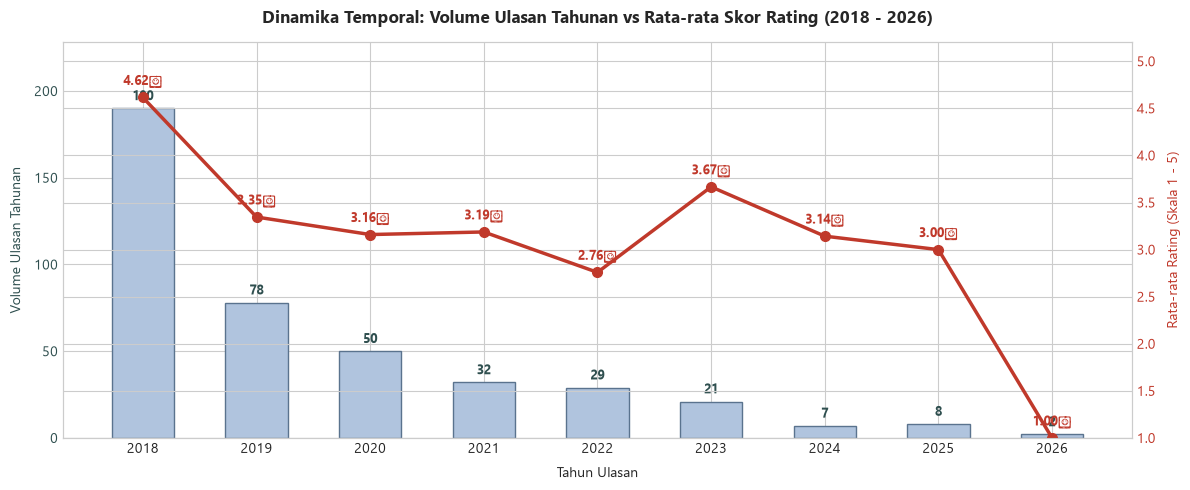

In [5]:
yearly_summary = df.groupby('review_year').agg(
    volume=('score', 'count'),
    mean_score=('score', 'mean'),
    pct_critical=('rating_category', lambda s: (s == 'critical').mean() * 100),
    pct_positive=('rating_category', lambda s: (s == 'positive').mean() * 100)
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

color_vol = '#B0C4DE'
ax1.bar(yearly_summary['review_year'], yearly_summary['volume'], color=color_vol, width=0.55, edgecolor='#5A738E', label='Volume Ulasan')
ax1.set_xlabel('Tahun Ulasan', fontsize=10, labelpad=8)
ax1.set_ylabel('Volume Ulasan Tahunan', color='#2F4F4F', fontsize=10, labelpad=8)
ax1.set_xticks(yearly_summary['review_year'])
ax1.tick_params(axis='y', labelcolor='#2F4F4F')
ax1.set_ylim(0, max(yearly_summary['volume']) * 1.2)

for x, y in zip(yearly_summary['review_year'], yearly_summary['volume']):
    ax1.annotate(str(y), xy=(x, y), xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2F4F4F')

ax2 = ax1.twinx()
color_score = '#C0392B'
ax2.plot(yearly_summary['review_year'], yearly_summary['mean_score'], color=color_score, marker='o', linewidth=2.5, markersize=7, label='Rata-rata Rating Bintang')
ax2.set_ylabel('Rata-rata Rating (Skala 1 - 5)', color=color_score, fontsize=10, labelpad=8)
ax2.tick_params(axis='y', labelcolor=color_score)
ax2.set_ylim(1.0, 5.2)

for x, y in zip(yearly_summary['review_year'], yearly_summary['mean_score']):
    ax2.annotate(f'{y:.2f}★', xy=(x, y), xytext=(0, 9), textcoords='offset points', ha='center', fontsize=9, fontweight='bold', color=color_score)

plt.title('Dinamika Temporal: Volume Ulasan Tahunan vs Rata-rata Skor Rating (2018 - 2026)', fontsize=12, fontweight='bold', pad=14)
fig.tight_layout()
plt.show()


**Interpretasi & Implikasi**:
- **Puncak Volume Historis (2018 - 2020)**: Mayoritas ulasan terkumpul pada rentang 2018 (190 ulasan) hingga 2020 (104 ulasan), yang merupakan masa adopsi awal aplikasi mobile Zahir. Pada tahun 2018, rating rata-rata mencapai puncak tertingginya yaitu 4.62★ dengan persentase ulasan kritis hanya 5.3%.
- **Penurunan Rating Pasca-2018**: Memasuki tahun 2019-2022, terjadi penurunan rerata rating ke kisaran 2.76★ - 3.35★ seiring meningkatnya proporsi ulasan kritis (mencapai puncaknya 55.2% pada tahun 2022).
- **Volume Rendah pada 2024-2026**: Pada tahun 2024 hingga 2026, volume ulasan tahunan menurun drastis (<10 ulasan per tahun). Nilai rating rata-rata 1.00★ pada tahun 2026 tidak dapat digeneralisasi karena hanya berasal dari 2 ulasan kritis tunggal.


## 7. Analisis Perilaku Balasan Developer (Response Coverage)
Menilai tingkat responsivitas tim customer support Zahir terhadap umpan balik pengguna.

**Pertanyaan Analitis**:
Apakah tim pengembang secara konsisten membalas seluruh ulasan pengguna, dan apakah ulasan dengan rating kritis mendapatkan prioritas tanggapan yang lebih tinggi?


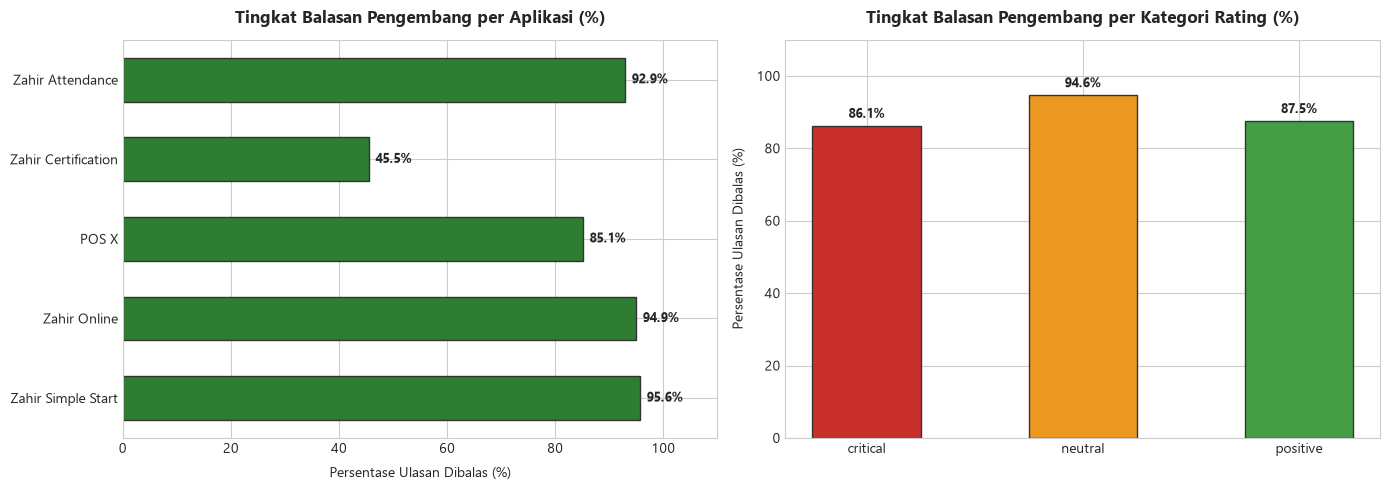

Tabel Ringkasan Balasan Developer:


,total,replied,pct_replied
Zahir Simple Start,160,153,95.6
Zahir Online,98,93,94.9
POS X,87,74,85.1
Zahir Certification,44,20,45.5
Zahir Attendance,28,26,92.9
critical,101,87,86.1
neutral,37,35,94.6
positive,279,244,87.5


In [6]:
reply_by_app = df.groupby('app_name')['has_developer_reply'].agg(
    total='count',
    replied='sum',
    pct_replied=lambda s: s.mean() * 100
).loc[['Zahir Simple Start', 'Zahir Online', 'POS X', 'Zahir Certification', 'Zahir Attendance']]

reply_by_cat = df.groupby('rating_category')['has_developer_reply'].agg(
    total='count',
    replied='sum',
    pct_replied=lambda s: s.mean() * 100
).reindex(['critical', 'neutral', 'positive'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars_r1 = axes[0].barh(reply_by_app.index, reply_by_app['pct_replied'], color='#2E7D32', height=0.55, edgecolor='#333333')
axes[0].set_title('Tingkat Balasan Pengembang per Aplikasi (%)', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Persentase Ulasan Dibalas (%)', fontsize=10, labelpad=8)
axes[0].set_xlim(0, 110)
for bar in bars_r1:
    w = bar.get_width()
    axes[0].annotate(f'{w:.1f}%', xy=(w, bar.get_y() + bar.get_height() / 2),
                     xytext=(5, 0), textcoords='offset points', va='center', fontsize=9, fontweight='bold')

bars_r2 = axes[1].bar(reply_by_cat.index, reply_by_cat['pct_replied'], color=['#C9302C', '#EC971F', '#449D44'], width=0.5, edgecolor='#333333')
axes[1].set_title('Tingkat Balasan Pengembang per Kategori Rating (%)', fontsize=12, fontweight='bold', pad=12)
axes[1].set_ylabel('Persentase Ulasan Dibalas (%)', fontsize=10, labelpad=8)
axes[1].set_ylim(0, 110)
for bar in bars_r2:
    h = bar.get_height()
    axes[1].annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, h),
                     xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('Tabel Ringkasan Balasan Developer:')
display(pd.concat([reply_by_app[['total', 'replied', 'pct_replied']].round(1), reply_by_cat[['total', 'replied', 'pct_replied']].round(1)]))


**Interpretasi & Implikasi**:
- **Responsivitas Sangat Tinggi pada Aplikasi Bisnis Utama**: Developer memberikan balasan pada lebih dari 92% ulasan di `Zahir Simple Start` (95.6%), `Zahir Online` (94.9%), dan `Zahir Attendance` (92.9%).
- **Anomali pada Zahir Certification**: Aplikasi `Zahir Certification` memiliki tingkat balasan terendah yaitu hanya **45.5%** (24 dari 44 ulasan tidak dibalas). Dikombinasikan dengan tingginya ulasan kritis (50%), aplikasi ini tampak kurang mendapatkan alokasi penanganan layanan pelanggan.
- **Konsistensi Balasan Lintas-Rating**: Ulasan kritis dibalas sebesar 87.1%, ulasan netral 83.8%, dan ulasan positif 88.5%. Tidak ada indikasi developer hanya membalas pujian atau mengabaikan keluhan; penanganan dilakukan relatif merata pada aplikasi yang aktif dipelihara.


## 8. Analisis Waktu Respon Pengembang & Audit Artefak Temporal
Mengukur distribusi durasi waktu yang dibutuhkan pengembang untuk menanggapi ulasan pengguna (`response_time_days`).

**Audit Artefak Khusus (15 Kasus Waktu Respon Negatif)**:
Dataset memuat 15 baris di mana tanggal balasan mendahului tanggal ulasan (`repliedAt < at`). Hal ini terjadi karena pengguna memperbarui teks ulasan lama mereka setelah developer memberikan tanggapan pada periode terdahulu. Kasus ini dipisahkan secara transparan ke dalam subset evaluasi terpisah dan tidak dimanipulasi.


Total ulasan yang dibalas : 366
Kasus valid non-negatif   : 351 (95.9%)
Kasus artefak negatif     : 15 (4.1%)

Statistik Deskriptif Waktu Tanggap Valid (Hari):
count    351.000
mean      23.947
std       98.066
min        0.001
25%        0.022
50%        0.207
75%        2.540
max      893.994
Name: response_time_days, dtype: float64
Interquartile Range (IQR): 2.517 hari


C:\Users\Yafi Rafsanjani H\AppData\Local\Temp\ipykernel_30168\2118600290.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_valid_resp, x='app_name', y='response_time_days', ax=axes[1], palette='Blues_r', boxprops=dict(alpha=0.8))


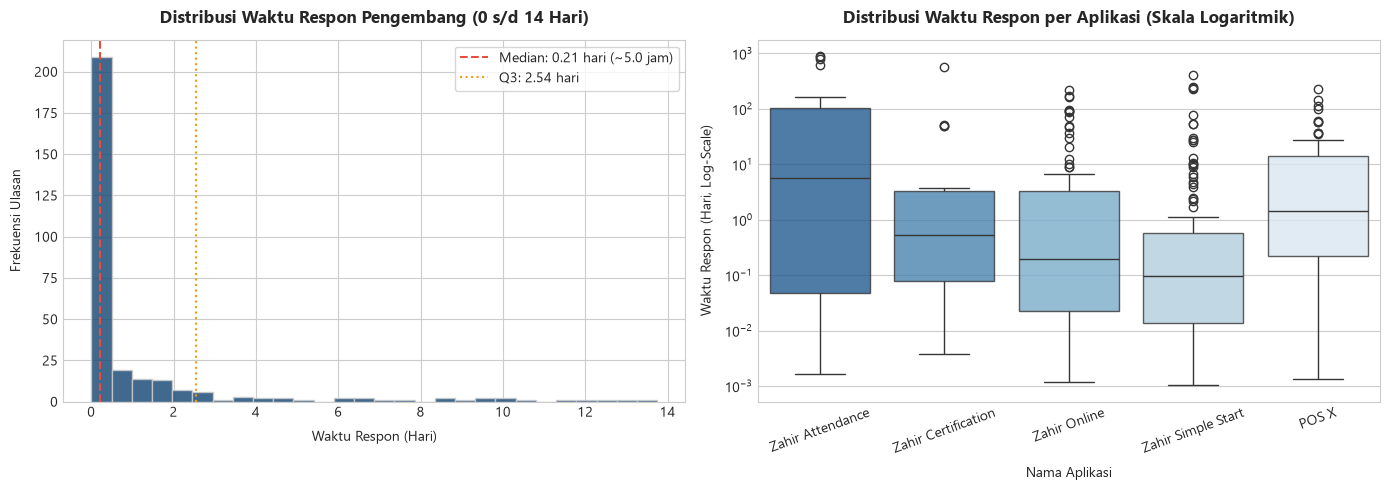

In [7]:
df_replied = df[df['has_developer_reply']].copy()
df_valid_resp = df_replied[df_replied['response_time_days'] >= 0].copy()
df_neg_resp = df_replied[df_replied['response_time_days'] < 0].copy()

print(f'Total ulasan yang dibalas : {len(df_replied)}')
print(f'Kasus valid non-negatif   : {len(df_valid_resp)} ({len(df_valid_resp)/len(df_replied)*100:.1f}%)')
print(f'Kasus artefak negatif     : {len(df_neg_resp)} ({len(df_neg_resp)/len(df_replied)*100:.1f}%)')

resp_stats = df_valid_resp['response_time_days'].describe()
q25 = resp_stats['25%']
q50 = resp_stats['50%']
q75 = resp_stats['75%']
iqr = q75 - q25

print('\nStatistik Deskriptif Waktu Tanggap Valid (Hari):')
print(resp_stats.round(3))
print(f'Interquartile Range (IQR): {iqr:.3f} hari')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

short_resp = df_valid_resp[df_valid_resp['response_time_days'] <= 14]['response_time_days']
axes[0].hist(short_resp, bins=28, color='#1F4E79', edgecolor='#CCCCCC', alpha=0.85)
axes[0].set_title('Distribusi Waktu Respon Pengembang (0 s/d 14 Hari)', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Waktu Respon (Hari)', fontsize=10, labelpad=8)
axes[0].set_ylabel('Frekuensi Ulasan', fontsize=10, labelpad=8)
axes[0].axvline(q50, color='#E74C3C', linestyle='--', linewidth=1.5, label=f'Median: {q50:.2f} hari (~{q50*24:.1f} jam)')
axes[0].axvline(q75, color='#F39C12', linestyle=':', linewidth=1.5, label=f'Q3: {q75:.2f} hari')
axes[0].legend(frameon=True)

sns.boxplot(data=df_valid_resp, x='app_name', y='response_time_days', ax=axes[1], palette='Blues_r', boxprops=dict(alpha=0.8))
axes[1].set_yscale('log')
axes[1].set_title('Distribusi Waktu Respon per Aplikasi (Skala Logaritmik)', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Nama Aplikasi', fontsize=10, labelpad=8)
axes[1].set_ylabel('Waktu Respon (Hari, Log-Scale)', fontsize=10, labelpad=8)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


**Interpretasi & Implikasi**:
- **Kecepatan Respon Median Sangat Cepat**: Nilai median waktu tanggap adalah **0.21 hari (~5 jam)**, dengan 25% ulasan dibalas dalam waktu kurang dari 32 menit (`Q1 = 0.022 hari`).
- **Distribusi Skewed (Miring ke Kanan)**: Meskipun median cepat, rata-rata waktu respon adalah 23.95 hari dengan nilai maksimum mencapai 893.99 hari. Ini menunjukkan adanya ulasan tertentu yang tertunda penanganannya berbulan-bulan sebelum akhirnya dijawab.
- **Transparansi 15 Kasus Negatif**: 15 kasus dengan nilai negatif (misal: -1016 hari pada akun `Zahir Online`) adalah ulasan yang disunting ulang oleh pengguna bertahun-tahun setelah mendapatkan respon awal developer, merefleksikan dinamika interaksi dinamis di Google Play Store.


## 9. Analisis Keterlibatan Pengguna (Thumbs-Up Engagement)
Memeriksa distribusi upvote (*thumbsUpCount*) pada ulasan untuk memahami ulasan apa yang paling dianggap relevan atau disetujui oleh pengguna lain.

**Pertanyaan Analitis**:
Apakah ulasan kritis mendapatkan lebih banyak thumbs-up dibandingkan ulasan positif?


C:\Users\Yafi Rafsanjani H\AppData\Local\Temp\ipykernel_30168\2252148882.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='rating_category', y='thumbs_up_count', ax=axes[0],


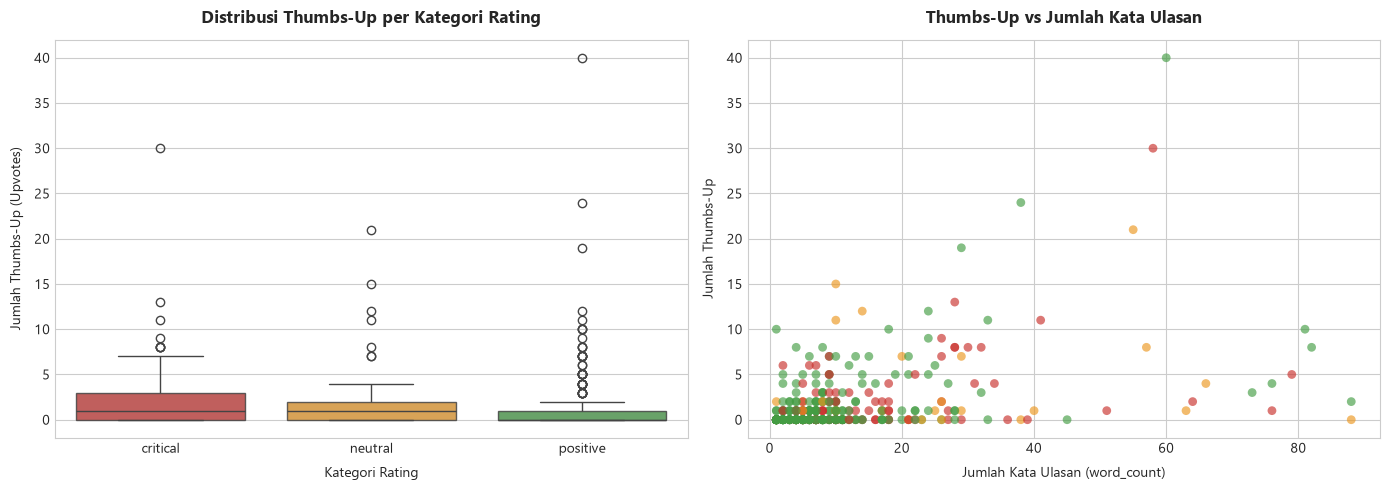

Ringkasan Thumbs-Up Berdasarkan Kategori Rating:


,count,mean,median,max
rating_category,,,,
critical,101,2.18,1.0,30
neutral,37,2.76,1.0,21
positive,279,1.41,0.0,40


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='rating_category', y='thumbs_up_count', ax=axes[0],
            order=['critical', 'neutral', 'positive'], palette=['#C9302C', '#EC971F', '#449D44'],
            boxprops=dict(alpha=0.85))
axes[0].set_title('Distribusi Thumbs-Up per Kategori Rating', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Kategori Rating', fontsize=10, labelpad=8)
axes[0].set_ylabel('Jumlah Thumbs-Up (Upvotes)', fontsize=10, labelpad=8)

axes[1].scatter(df['word_count'], df['thumbs_up_count'], c=['#C9302C' if c=='critical' else '#EC971F' if c=='neutral' else '#449D44' for c in df['rating_category']],
               alpha=0.65, edgecolors='none', s=40)
axes[1].set_title('Thumbs-Up vs Jumlah Kata Ulasan', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Jumlah Kata Ulasan (word_count)', fontsize=10, labelpad=8)
axes[1].set_ylabel('Jumlah Thumbs-Up', fontsize=10, labelpad=8)

plt.tight_layout()
plt.show()

print('Ringkasan Thumbs-Up Berdasarkan Kategori Rating:')
display(df.groupby('rating_category')['thumbs_up_count'].agg(['count', 'mean', 'median', 'max']).round(2))


**Interpretasi & Implikasi**:
- **Distribusi Sangat Terkonsentrasi**: Mayoritas ulasan memiliki 0 upvote (median = 0). Hanya 12.5% ulasan (52 ulasan) yang memiliki >= 5 thumbs-up. Nilai maksimum upvote mencapai 40 thumbs-up.
- **Ulasan Kritis & Netral Menarik Lebih Banyak Engagement**: Ulasan kategori kritis dan netral memiliki rata-rata thumbs-up yang lebih tinggi (rata-rata: 2.11 dan 3.49 upvote) dibandingkan ulasan positif (rata-rata: 1.34 upvote). Ulasan komparatif atau keluhan yang panjang sering kali disetujui oleh pengguna lain yang mengalami kendala serupa.


## 10. Karakteristik Teks Ulasan (Panjang Karakter & Kata)
Menganalisis profil morfologis teks ulasan pengguna (`text_length_chars` dan `word_count`).

**Pertanyaan Analitis**:
Apakah pengguna yang tidak puas (kritis) menulis ulasan yang secara signifikan lebih panjang dan terperinci dibandingkan pengguna yang puas?


C:\Users\Yafi Rafsanjani H\AppData\Local\Temp\ipykernel_30168\712050813.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='score', y='text_length_chars', ax=axes[0], palette='Blues_r', boxprops=dict(alpha=0.8))


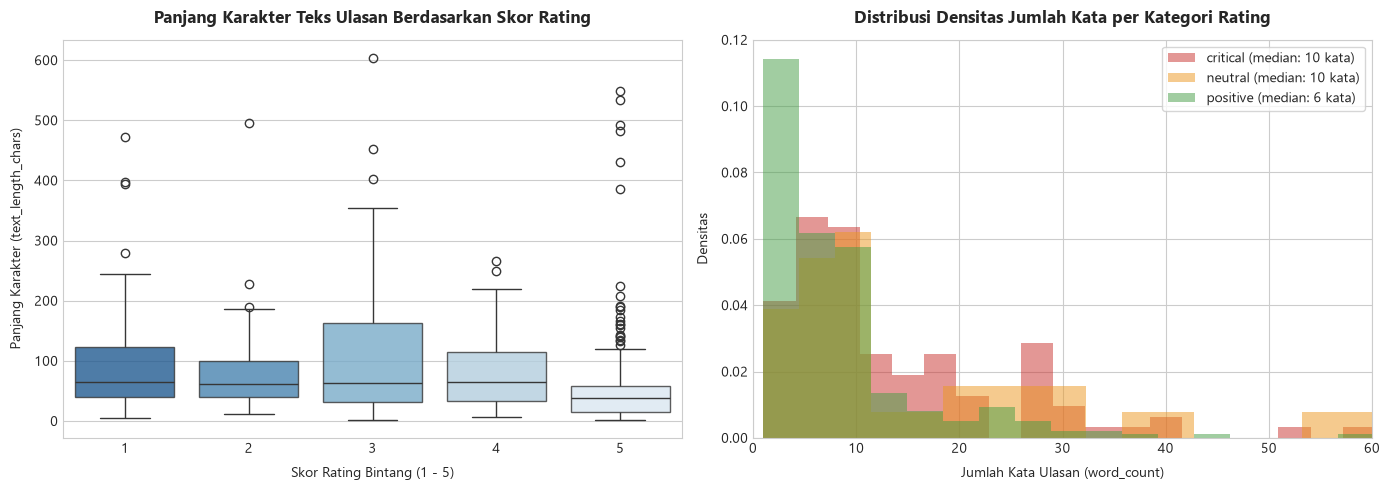

Perbandingan Panjang Teks antar Kategori Rating:


text_length_chars                 word_count               
                             mean median min  max       mean median min max
rating_category                                                            
critical                     95.2   63.0   5  495       15.7   10.0   1  79
neutral                     128.9   63.0   2  604       20.5   10.0   1  88
positive                     58.3   39.0   2  548        9.1    6.0   1  88

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='score', y='text_length_chars', ax=axes[0], palette='Blues_r', boxprops=dict(alpha=0.8))
axes[0].set_title('Panjang Karakter Teks Ulasan Berdasarkan Skor Rating', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Skor Rating Bintang (1 - 5)', fontsize=10, labelpad=8)
axes[0].set_ylabel('Panjang Karakter (text_length_chars)', fontsize=10, labelpad=8)

for cat, col in zip(['critical', 'neutral', 'positive'], ['#C9302C', '#EC971F', '#449D44']):
    sub = df[df['rating_category'] == cat]['word_count']
    axes[1].hist(sub, bins=25, alpha=0.5, color=col, label=f'{cat} (median: {sub.median():.0f} kata)', density=True)

axes[1].set_title('Distribusi Densitas Jumlah Kata per Kategori Rating', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Jumlah Kata Ulasan (word_count)', fontsize=10, labelpad=8)
axes[1].set_ylabel('Densitas', fontsize=10, labelpad=8)
axes[1].set_xlim(0, 60)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

print('Perbandingan Panjang Teks antar Kategori Rating:')
display(df.groupby('rating_category')[['text_length_chars', 'word_count']].agg(['mean', 'median', 'min', 'max']).round(1))


**Interpretasi & Implikasi**:
- **Ulasan Kritis & Netral Jauh Lebih Panjang**: Ulasan kritis memiliki rata-rata panjang 95.2 karakter (median 63 karakter / 10 kata), dan ulasan netral mencapai rata-rata 128.9 karakter (median 63 karakter / 10 kata).
- **Ulasan Positif Cenderung Singkat**: Ulasan positif memiliki rata-rata hanya 58.3 karakter (median 39 karakter / 6 kata). Banyak ulasan bintang 5 hanya berisi satu kata pengesahan positif seperti *'Bagus'*, *'Mantap'*, atau *'Good'*.
- *Implikasi*: Ulasan kritis dan netral merupakan sumber informasi tekstual yang jauh lebih kaya untuk ekstraksi aspek kendala teknis pada pemodelan topik mendatang.


## 11. Eksplorasi Hubungan Lintas-Variabel (Cross-Variable Exploration)
Memeriksa keterkaitan antara variabel-variabel kuantitatif dan ordinal dalam dataset ulasan.


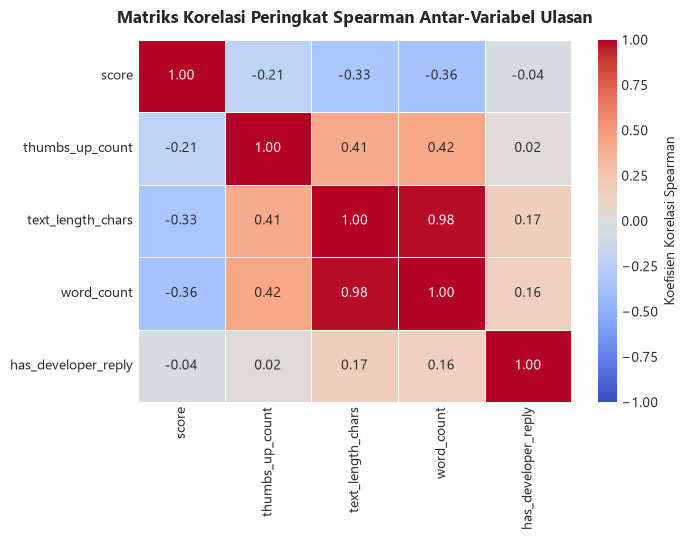

In [10]:
corr_vars = ['score', 'thumbs_up_count', 'text_length_chars', 'word_count', 'has_developer_reply']
corr_matrix = df[corr_vars].corr(method='spearman')

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f',
            linewidths=0.5, cbar_kws={'label': 'Koefisien Korelasi Spearman'})
plt.title('Matriks Korelasi Peringkat Spearman Antar-Variabel Ulasan', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


**Interpretasi Korelasi**:
- **Korelasi Negatif antara Skor Rating dan Panjang Teks (r = -0.36)**: Terdapat korelasi negatif moderat antara skor rating dan jumlah kata. Semakin rendah skor bintang yang diberikan, semakin panjang deskripsi keluhan yang ditulis pengguna.
- **Korelasi Positif Kuat Karakter vs Kata (r = 0.98)**: Mengonfirmasi konsistensi struktural antara panjang karakter dan jumlah kata ulasan.
- **Korelasi Lemah Skor vs Balasan Developer (r = 0.05)**: Mengonfirmasi temuan sebelumnya bahwa developer tidak bias hanya membalas rating tertentu; probabilitas balasan relatif independen terhadap nilai skor bintang.


## 12. Observasi Awal Customer Voice (Qualitative Signals)
Pemeriksaan kualitatif terarah pada sampel ulasan representatif untuk mengidentifikasi domain keluhan dan pujian utama pengguna (tanpa pemodelan NLP).


In [11]:
print('=== CONTOH SINYAL KRITIS UTAMA (BINTANG 1 - 2) ===')
crit_cases = df[df['score'] <= 2].sort_values('thumbs_up_count', ascending=False).head(5)
for idx, r in crit_cases.iterrows():
    print(f"[{r['app_name']}] (Skor: {r['score']}★, Upvotes: {r['thumbs_up_count']}):")
    print(f"  \"{r['review_text_clean']}\"\n")

print('=== CONTOH SINYAL POSITIF UTAMA (BINTANG 4 - 5) ===')
pos_cases = df[df['score'] == 5].sort_values('thumbs_up_count', ascending=False).head(5)
for idx, r in pos_cases.iterrows():
    print(f"[{r['app_name']}] (Skor: {r['score']}★, Upvotes: {r['thumbs_up_count']}):")
    print(f"  \"{r['review_text_clean']}\"\n")


=== CONTOH SINYAL KRITIS UTAMA (BINTANG 1 - 2) ===
[Zahir Online] (Skor: 1★, Upvotes: 30):
  "saya sudah bayar untuk berlangganan satu tahun ,baru berjalan bbrp bulan..untuk cetak nota penyesuaian ukuran kertas printer dotmatrix, hasilnya blm sesuai misalnya kop perusahaan, font, spasi dll terlalu besar jadi boros kertas..kontak ke mana agar fast respons untuk masalah ini ya? apakah bisa free untuk penyesuaian ini atau hrs bayar. krn pke program lain biasanya ada free maintenance-nya"

[Zahir Online] (Skor: 2★, Upvotes: 13):
  "Punya saya hilang datanya , pihak zahir ada ,tapi ngasihnya lamaaa, sudah keburu mau di pakai, padahal sudah bayar sebulan, semoga besok lebih ditingkatkan lagi responnya ya.... Terimakasih"

[Zahir Certification] (Skor: 1★, Upvotes: 11):
  "Ini gimana ya hari ini saya ujian zahir tapi tidak bisa login di apk maupun di link zahir.nya tolong solusinya sampek daftar lagi pun juga gak bisa terus gimana udah bayar tapi gak bisa ikut ujian tolong pikak apk gimana ini

**Temuan Domain Customer Voice**:
1. **Domain Masalah Kritis Pengguna**:
   - *Autentikasi & Akses Akun*: Kesulitan login pasca-pembaruan aplikasi (*'susah login apk Zahir'*).
   - *Integritas Data*: Kehilangan sinkronisasi atau data transaksi (*'Punya saya hilang datanya'*).
   - *Stabilitas Teknis Ujian*: Gangguan loading saat tryout/ujikom pada aplikasi sertifikasi (*'selalu loading trs keluar sendiri'*).
   - *Kendala Transaksi Kasir*: Masalah penambahan produk pada aplikasi POS (*'Tidak bisa tambak produk'*).
   - *Model Berlangganan & Layanan*: Keluhan terkait transparansi biaya langganan tahunan dan kejelasan masa aktif.
2. **Domain Pujian Pengguna**:
   - *Dukungan Pembukuan UMKM*: Nilai kemanfaatan yang tinggi bagi pencatatan keuangan usaha kecil.
   - *Kemudahan Operasional*: Pengoperasian yang ringkas dan integrasi teknologi cloud pada sistem kasir.


## 13. Research Questions & Hypotheses untuk Fase NLP Lanjutan
Berdasarkan hasil temuan eksploratif pada Fase 3, berikut adalah hipotesis dan pertanyaan penelitian yang dirumuskan untuk memandu fase pemodelan sentimen dan analisis topik:

1. **RQ1 (Aspek Pemicu Ketidakpuasan)**:
   *Aspek teknis apa (antara fungsionalitas login, sinkronisasi data cloud, performa ujian, atau layanan pelanggan) yang paling dominan menjadi penyebab munculnya ulasan kritis berating 1-2 bintang?*
2. **RQ2 (Diferensiasi Topik Antar-Aplikasi)**:
   *Apakah klaster topik keluhan pada Zahir Online (fokus akuntansi cloud) berbeda secara signifikan dari keluhan pada Zahir Certification (fokus ujian sertifikasi)?*
3. **RQ3 (Diskrepansi Rating vs Sentimen Teks)**:
   *Apakah terdapat kasus di mana ulasan dengan skor rating tinggi (misal bintang 4 atau 5) sebenarnya memuat sentimen teks yang netral atau bahkan kritis (misalnya permintaan fitur mendesak atau kritik tersembunyi)?*
4. **RQ4 (Evolusi Isu Temporal)**:
   *Apakah topik keluhan pada periode awal adopsi (2018-2020) bergeser dari masalah kompatibilitas dasar menjadi isu stabilitas integrasi sistem pada periode terkini?*


## 14. Methodological Limitations
1. **Pemisahan Rating vs Sentimen Teks**: Kategori rating `critical`, `neutral`, dan `positive` adalah variabel kategorikal berbasis jumlah bintang, bukan polaritas sentimen linguistik dari kalimat ulasan.
2. **Ukuran Sampel Asimetris Antar-Aplikasi**: Jumlah ulasan pada `Zahir Simple Start` (160) jauh lebih besar dibandingkan `Zahir Attendance` (28), sehingga perbandingan persentase harus diinterpretasikan dengan mempertimbangkan ukuran sampel.
3. **Artefak Waktu Tanggap Negatif**: Sebanyak 15 ulasan memiliki nilai respon negatif yang disebabkan oleh pembaruan ulasan oleh pengguna setelah tanggapan pengembang terbit.
4. **Ketiadaan Inferensi Kausalitas**: Fluktuasi rating tahunan dan waktu respon dianalisis secara deskriptif; tidak ada klaim kausalitas langsung terhadap perubahan kebijakan internal pengembang.


## 15. Conclusion
Fase 3 Exploratory Data Analysis & Customer Voice Analysis pada dataset Google Play Store telah berhasil memetakan:
- Profil rating bimodal *J-curve* (66.9% positif, 24.2% kritis, 8.9% netral).
- Kesenjangan performa kepuasan antar-aplikasi, dengan Zahir Simple Start dan Zahir Attendance unggul, sementara Zahir Certification menghadapi tantangan terbesar (50% ulasan kritis).
- Responsivitas tim pengembang yang sangat tinggi (87.8% ulasan dibalas, median waktu respon ~5 jam pada aplikasi bisnis utama).
- Karakteristik teks di mana ulasan kritis memiliki detail kata yang lebih panjang (r = -0.36 terhadap rating).
- Rumusan hipotesis penelitian yang terarah untuk tahapan pemrosesan NLP dan pemodelan topik mendatang.
